# Langkah 0 - Import Library



In [5]:
from pathlib import Path
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np
import pandas as pd

In [6]:
train_dir = "data/images/training/"
test_dir = "data/images/test/"

# Langkah 1 - Load Data dan Visualisasikan

In [7]:
def load_dataset(img_dir):
  p = Path(img_dir)
  dirs = p.glob('*')
  img_list = []
  
  for dir in dirs:
    label = str(dir).split('/')[-1]
    for file in dir.glob('*.jpg'):
      img = mpimg.imread(file)
      if not img is None:
        img_list.append((img, label))
  return img_list

In [8]:
train_img = load_dataset(train_dir)

In [9]:
train_img[0]

(array([[[158, 194, 218],
         [158, 194, 218],
         [158, 194, 218],
         ...,
         [176, 209, 228],
         [177, 210, 229],
         [177, 210, 229]],
 
        [[158, 194, 218],
         [158, 194, 218],
         [158, 194, 218],
         ...,
         [180, 213, 232],
         [180, 213, 232],
         [180, 213, 232]],
 
        [[158, 194, 218],
         [158, 194, 218],
         [158, 194, 218],
         ...,
         [177, 210, 229],
         [177, 210, 229],
         [177, 210, 229]],
 
        ...,
 
        [[ 35,  40,  43],
         [ 38,  43,  46],
         [ 39,  44,  47],
         ...,
         [ 65,  73,  75],
         [ 65,  73,  75],
         [ 65,  73,  75]],
 
        [[ 36,  41,  44],
         [ 38,  43,  46],
         [ 39,  44,  47],
         ...,
         [ 68,  76,  78],
         [ 68,  76,  78],
         [ 65,  73,  75]],
 
        [[ 37,  41,  44],
         [ 38,  43,  46],
         [ 39,  44,  47],
         ...,
         [ 68,  76,  78],
  

In [10]:
pick_random = np.random.randint(0, len(train_img))

print(f'Image {pick_random}')
print(train_img[pick_random][0].shape)

Image 187
(700, 1280, 3)


In [11]:
def random_img_viz(img_list):
  rand_num = np.random.randint(0, len(img_list))

  img = img_list[rand_num][0]
  label = img_list[rand_num][1]
  label_str = 'day' if label == 1 else 'night'

  plt.imshow(img)
  print(f'Shape\t: {img.shape}')
  print(f'Label\t: {label}')

Shape	: (458, 800, 3)
Label	: data\images\training\night


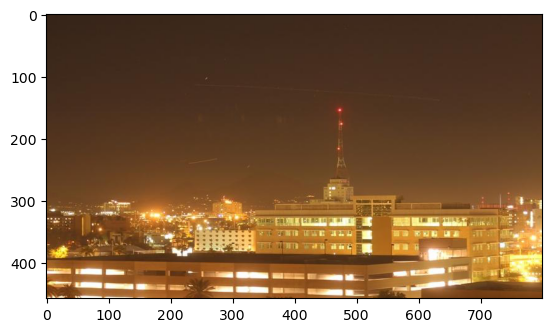

In [12]:
random_img_viz(train_img)

# Langkah 3 - Pra Pengolahan Data


In [13]:
def standarized_input(image):
  std_img = cv2.resize(image, (1100,600))

  return std_img

In [14]:
	def label_encoder(label):
		num_val = 0

		if(label == 'day'):
			num_val = 1

		return num_val

In [15]:
def preprocess(img_list):
  std_img_list = []
  for item in img_list:
    image = item[0]
    label = item[1]

    std_img = standarized_input(image)

    img_label = label_encoder(label)
    std_img_list.append((std_img, img_label))
  
  return std_img_list

In [16]:
train_std_img_list = preprocess(train_img)

In [17]:
pick_random = np.random.randint(0, len(train_std_img_list))

print(f'Image {pick_random}')
print(train_std_img_list[pick_random][0].shape)

Image 95
(600, 1100, 3)


# Langkah 4 - Ekstraksi Fitur

In [18]:
def avg_brightness(image):
  img_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

  sum_brightness = np.sum(img_hsv[:,:,2]) 
  area = image.shape[0] * image.shape[1]
  avg = sum_brightness / area

  return avg

Image 175
Avg Brighness: 73.4031


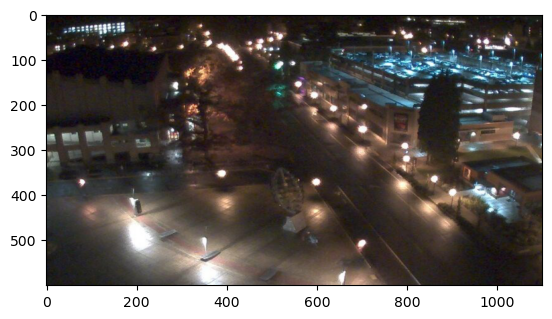

In [19]:
rand_img = np.random.randint(0, len(train_std_img_list))

feature_img = train_std_img_list[rand_img][0]

avg_img = avg_brightness(feature_img)

print(f'Image {rand_img}')
print(f'Avg Brighness: {avg_img:.4f}')
plt.imshow(feature_img)

# Langkah 5 - Klasifikasi dengan Metode Threshold

In [20]:
def predict_label(img, threshold):
  avg = avg_brightness(img)
  pred = 0

  if avg > threshold:
    pred = 1
    
  return pred

Image 46
Actual label: 0
Predicted label: 0


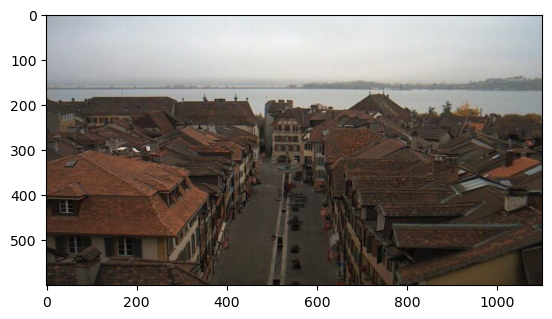

In [21]:
rand_img = np.random.randint(0, len(train_std_img_list))

pred = predict_label(train_std_img_list[rand_img][0], threshold=120)

print(f'Image {rand_img}')
print(f'Actual label: {train_std_img_list[rand_img][1]}')
print(f'Predicted label: {pred}')
plt.imshow(train_std_img_list[rand_img][0])

# Langkah 6 - Evaluasi Manual

In [22]:
def evaluate(img_list, threshold):
  miss_labels = []

  for file in img_list:
    img = file[0]
    label = file[1]

    pred_label = predict_label(img, threshold)

    if pred_label != label:
      miss_labels.append((img, pred_label, label))
    
  total_img = len(img_list)
  corr_pred = total_img - len(miss_labels)
  accuracy = corr_pred / total_img

  print(f'Accuracy: {accuracy:.4f}')

In [23]:
evaluate(train_std_img_list, threshold=120)

Accuracy: 0.6583


In [24]:
test_img = load_dataset(test_dir)
test_std_img_list = preprocess(test_img)
evaluate(test_std_img_list, threshold=120)

Accuracy: 0.6062


# Langkah 4 Alternatif - Membuat Feature Vectors.

In [25]:
def extract_avg_bright_feature(img_list):
  avg_list = []
  labels = []

  for img in img_list:
    img_avg = avg_brightness(img[0])
    img_label = img[1]

    avg_list.append(img_avg)
    labels.append(img_label)
    
  data = np.column_stack((avg_list, labels))
  df = pd.DataFrame(data, columns=['AVG_BRIGHT', 'LABELS'])
	
  return df

In [26]:
train_avg_img = extract_avg_bright_feature(train_std_img_list)
print(f'Shape: {train_avg_img.shape}')
train_avg_img.head()

Shape: (240, 2)


,AVG_BRIGHT,LABELS
0,175.129871,0.0
1,192.954773,0.0
2,132.141432,0.0
3,199.784797,0.0
4,109.964702,0.0


In [27]:
test_avg_img = extract_avg_bright_feature(test_std_img_list)
print(f'Shape: {test_avg_img.shape}')
test_avg_img.head()

Shape: (160, 2)


,AVG_BRIGHT,LABELS
0,194.267453,0.0
1,157.844245,0.0
2,201.646592,0.0
3,191.273192,0.0
4,188.152729,0.0


# Langkah 5 - Buat Model SVM

In [28]:
from sklearn.svm import SVC

X_train = train_avg_img.iloc[:,0].values.reshape(-1,1)
y_train = train_avg_img.iloc[:,1]
X_test = test_avg_img.iloc[:,0].values.reshape(-1,1)
y_test = test_avg_img.iloc[:,1]

model = SVC()
model.fit(X_train, y_train)

ValueError: The number of classes has to be greater than one; got 1 class

# Langkah 6 - Evaluasi

In [ ]:
from sklearn.metrics import accuracy_score

y_train_pred = model.predict(X_train)
acc_train = accuracy_score(y_train, y_train_pred)
y_test_pred = model.predict(X_test)
acc_test = accuracy_score(y_test, y_test_pred)

print(f'Accuracy on train: {acc_train}')
print(f'Accuracy on test: {acc_test}')